<a href="https://www.kaggle.com/code/aishaalal/multi-cancer-detection-using-cnn?scriptVersionId=347415821" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

PART 1 — Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))
print(tf.__version__)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
2.20.0


PART 2 — Define Settings

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

DATASET_DIR = "/kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer"

print("Dataset path:", DATASET_DIR)
print("Classes:", os.listdir(DATASET_DIR))

Dataset path: /kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer
Classes: ['Cervical Cancer', 'Lung and Colon Cancer', 'Oral Cancer', 'ALL', 'Kidney Cancer', 'Breast Cancer', 'Lymphoma', 'Brain Cancer']


PART 3 — Data Preprocessing

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

PART 4 — Create Training and Validation Generators

In [5]:
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print("Class names:", class_names)
print("Training samples:", train_generator.samples)
print("Validation samples:", valid_generator.samples)

Found 104002 images belonging to 8 classes.
Found 26000 images belonging to 8 classes.
Class names: ['ALL', 'Brain Cancer', 'Breast Cancer', 'Cervical Cancer', 'Kidney Cancer', 'Lung and Colon Cancer', 'Lymphoma', 'Oral Cancer']
Training samples: 104002
Validation samples: 26000


PART 5 — Show Sample Images

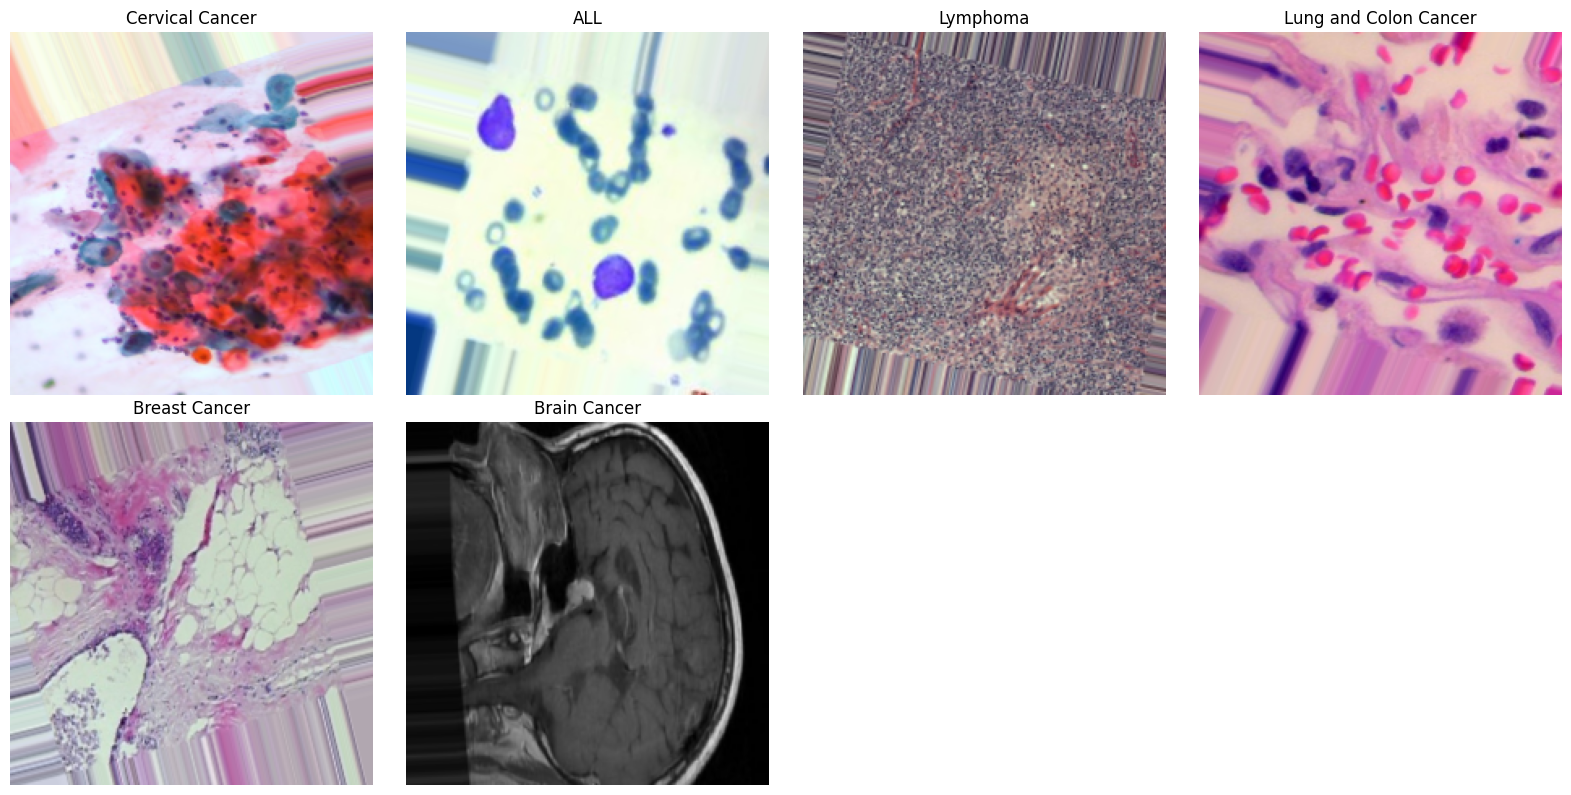

In [6]:
images, labels = next(train_generator)

plt.figure(figsize=(16, 8))

shown_classes = []

for i in range(len(images)):
    class_index = np.argmax(labels[i])
    class_name = class_names[class_index]

    if class_name not in shown_classes:
        shown_classes.append(class_name)

        plt.subplot(2, 4, len(shown_classes))
        plt.imshow(images[i])
        plt.title(class_name)
        plt.axis("off")

    if len(shown_classes) == len(class_names):
        break

plt.tight_layout()
plt.show()

PART 6 — Build CNN Model with MobileNetV2

In [7]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(len(class_names), activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

I0000 00:00:1788592273.881756      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

PART 7 — Compile Model

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

PART 8 — Train Model

In [9]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=6,
    steps_per_epoch=500,
    validation_steps=300,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/6


I0000 00:00:1788592293.709959      86 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 463s 894ms/step - accuracy: 0.8774 - loss: 0.4098 - val_accuracy: 0.9538 - val_loss: 0.1432
Epoch 2/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 376s 754ms/step - accuracy: 0.9699 - loss: 0.1026 - val_accuracy: 0.9733 - val_loss: 0.0871
Epoch 3/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 368s 737ms/step - accuracy: 0.9774 - loss: 0.0731 - val_accuracy: 0.9845 - val_loss: 0.0506
Epoch 4/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 339s 679ms/step - accuracy: 0.9817 - loss: 0.0587 - val_accuracy: 0.9812 - val_loss: 0.0551
Epoch 5/6
500/500 ━━━━━━━━━━━━━━━━━━━━ 320s 642ms/step - accuracy: 0.9834 - loss: 0.0515 - val_accuracy: 0.9817 - val_loss: 0.0559


PART 9 — Accuracy Graph

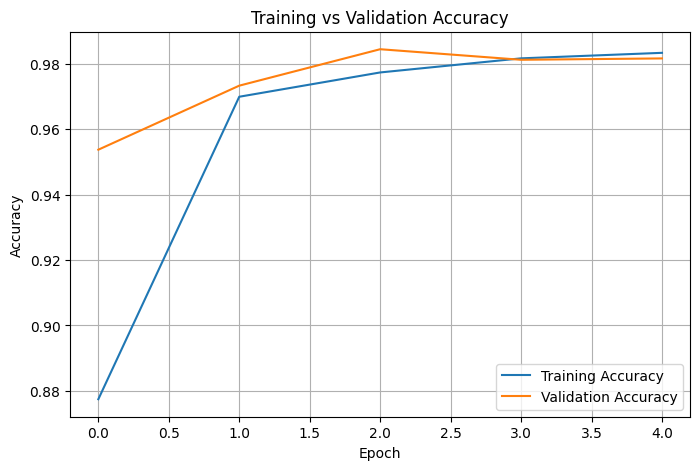

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

PART 10 — Loss Graph

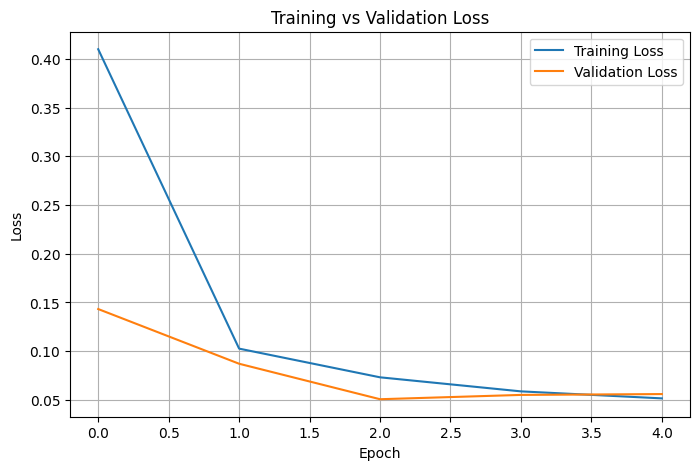

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

PART 11 — Classification Report

In [12]:
Y_pred = model.predict(valid_generator)

y_pred = np.argmax(
    Y_pred,
    axis=1
)

y_true = valid_generator.classes

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

813/813 ━━━━━━━━━━━━━━━━━━━━ 216s 260ms/step
                       precision    recall  f1-score   support

                  ALL       1.00      1.00      1.00      4000
         Brain Cancer       1.00      1.00      1.00      3000
        Breast Cancer       0.90      0.94      0.92      2000
      Cervical Cancer       0.94      0.96      0.95      5000
        Kidney Cancer       1.00      1.00      1.00      2000
Lung and Colon Cancer       0.94      0.90      0.92      5000
             Lymphoma       0.99      1.00      1.00      3000
          Oral Cancer       0.94      0.92      0.93      2000

             accuracy                           0.96     26000
            macro avg       0.96      0.97      0.96     26000
         weighted avg       0.96      0.96      0.96     26000



PART 12 — Confusion Matrix

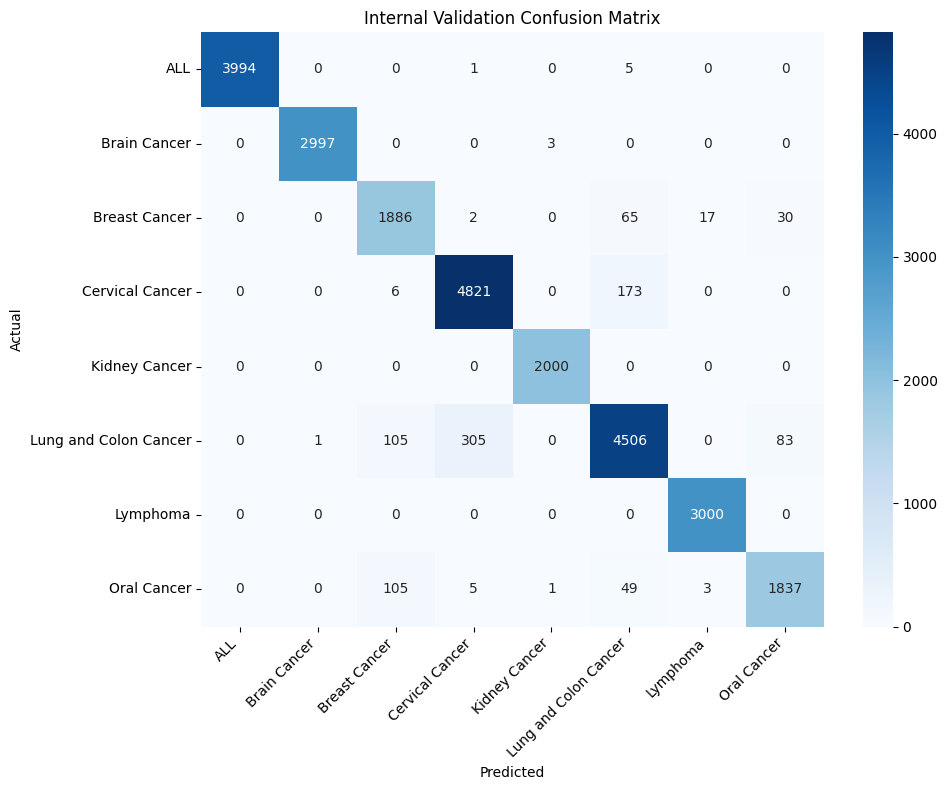

In [13]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Internal Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

PART 13 — Save Model as .h5

In [14]:
model.save("/kaggle/working/multi_cancer_model.h5")
print("Model saved successfully.")

Model saved successfully.


PART 14 — Predict One Image with Percentage

In [15]:
def predict_image(image_path):

    img = load_img(
        image_path,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )

    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    predictions = model.predict(
        img_array
    )[0]

    predicted_index = np.argmax(
        predictions
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = predictions[
        predicted_index
    ] * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(load_img(image_path))
    plt.axis("off")

    plt.title(
        f"{predicted_class}\nConfidence: {confidence:.2f}%"
    )

    plt.show()

    print(
        "Predicted class:",
        predicted_class
    )

    print(
        "Confidence:",
        f"{confidence:.2f}%"
    )

Part 15 - External Test Dataset

In [16]:
external_dir = "/kaggle/input/datasets/aishaalal/externaltest/TESTFILE/external_test"

external_datagen = ImageDataGenerator(
    rescale=1./255
)

external_generator = external_datagen.flow_from_directory(
    external_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    classes=class_names
)

print(
    "External samples:",
    external_generator.samples
)

print(
    "External class indices:",
    external_generator.class_indices
)

Found 80 images belonging to 8 classes.
External samples: 80
External class indices: {'ALL': 0, 'Brain Cancer': 1, 'Breast Cancer': 2, 'Cervical Cancer': 3, 'Kidney Cancer': 4, 'Lung and Colon Cancer': 5, 'Lymphoma': 6, 'Oral Cancer': 7}


PART 16 — External Test Validation

In [17]:
external_loss, external_acc = model.evaluate(
    external_generator
)

print(
    f"External Test Loss: {external_loss:.4f}"
)

print(
    f"External Test Accuracy: {external_acc * 100:.2f}%"
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5625 - loss: 2.0018
External Test Loss: 2.0018
External Test Accuracy: 56.25%


Part 17 - External Classification Report

In [18]:
Y_pred_ext = model.predict(
    external_generator
)

y_pred_ext = np.argmax(
    Y_pred_ext,
    axis=1
)

y_true_ext = external_generator.classes

print(
    classification_report(
        y_true_ext,
        y_pred_ext,
        target_names=class_names,
        zero_division=0
    )
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
                       precision    recall  f1-score   support

                  ALL       0.90      0.90      0.90        10
         Brain Cancer       1.00      1.00      1.00        10
        Breast Cancer       0.11      0.20      0.14        10
      Cervical Cancer       1.00      1.00      1.00        10
        Kidney Cancer       1.00      1.00      1.00        10
Lung and Colon Cancer       0.06      0.10      0.07        10
             Lymphoma       0.00      0.00      0.00        10
          Oral Cancer       1.00      0.30      0.46        10

             accuracy                           0.56        80
            macro avg       0.63      0.56      0.57        80
         weighted avg       0.63      0.56      0.57        80



Part 18 - External Confusion Matrix

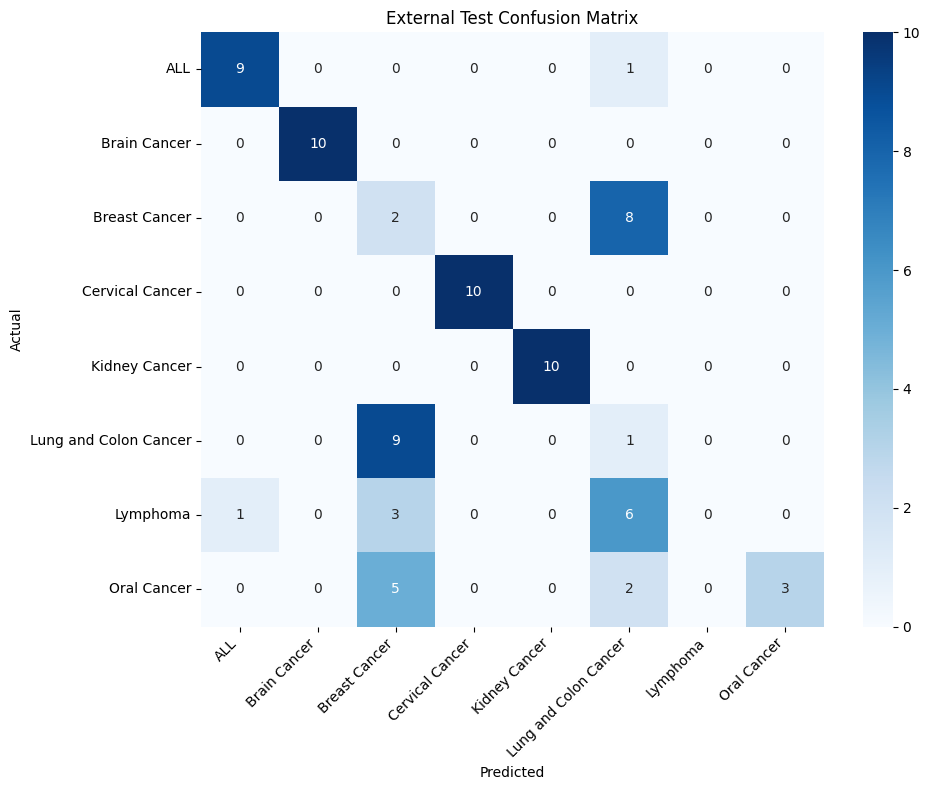

In [19]:
cm_ext = confusion_matrix(
    y_true_ext,
    y_pred_ext
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_ext,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "External Test Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Part 19 — Convert to TensorFlow Lite

In [20]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

tflite_model = converter.convert()

with open(
    "/kaggle/working/multi_cancer_model.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print(
    "TFLite model saved successfully."
)

INFO:tensorflow:Assets written to: /tmp/tmph1w26ytg/assets


INFO:tensorflow:Assets written to: /tmp/tmph1w26ytg/assets


Saved artifact at '/tmp/tmph1w26ytg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  132980200472016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132977067902352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132977067901968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132980200471824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132980200472208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132980200472400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132977067902160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132977067904272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132977067903888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132977067903696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13297706790350

W0000 00:00:1788594385.267565      23 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1788594385.267620      23 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1788594385.417155      23 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


Part 20 — Check Saved Files

In [21]:
print(
    os.listdir("/kaggle/working")
)

['multi_cancer_model.h5', 'multi_cancer_model.tflite', '__notebook__.ipynb']
